# Simulation Data: from a Gridded Field File to Field Line Geometry

Mageometry reads magnetic fields from simulation output (`mageometry.io`) and analyzes them with exactly the same geometry and tracing functions as model fields. This notebook walks the whole pipeline on a **synthetic but realistic dataset**: a T96 + dipole field sampled on a uniform grid and written in the XDMF + HDF5 convention used by many MHD codes. Because the reference field is known exactly, every step can be checked quantitatively — which is also how the library's own tests validate the pipeline.

Requires the optional `h5py` dependency (`pip install h5py`).

## Contents

1. [Write a compatible data file](#write)
2. [Load it: `load_xdmf` and `GriddedField`](#load)
3. [Interpolation accuracy: linear vs cubic](#interp)
4. [Curvature through the file](#curvature)
5. [Tracing through the data](#trace)
6. [Bringing your own data](#own)

In [1]:
import os
import tempfile

import numpy as np
import h5py
import matplotlib.pyplot as plt

from mageometry import (
    geopack, geopack_field, load_xdmf, GriddedField,
    trace_field_lines, field_line_curvature, field_line_frenet_frame,
)

%matplotlib inline

Load IGRF coefficients ...


<a id="write"></a>
## 1. Write a compatible data file

The accepted format is documented in [`docs/simulation_data_formats.md`](../../docs/simulation_data_formats.md). The essentials of the XDMF convention:

- `3DCORECTMesh` topology with `NumberOfElements="NZ NY NX"` — **slowest axis first**;
- `ORIGIN_DXDYDZ` geometry, again listed as (z, y, x);
- HDF5 datasets stored C-order with shape `(NZ, NY, NX)`.

`load_xdmf` transposes everything to Mageometry's `(NX, NY, NZ)` convention. The writer below is the recipe from the docs; the reference field is T96 + dipole sampled on a nightside block at Δ = 0.25 Re.

In [2]:
def write_xdmf_h5(dirpath, basename, x, y, z, bx, by, bz):
    # Write (nx, ny, nz) arrays as an XDMF + HDF5 pair in the (z, y, x) on-disk convention.
    nx, ny, nz = bx.shape
    origin = (x[0], y[0], z[0])
    spacing = (x[1] - x[0], y[1] - y[0], z[1] - z[0])
    h5_path = os.path.join(dirpath, basename + ".h5")
    xmf_path = os.path.join(dirpath, basename + ".xmf")
    with h5py.File(h5_path, "w") as f:
        for name, arr in (("BX", bx), ("BY", by), ("BZ", bz)):
            f.create_dataset(name, data=arr.transpose(2, 1, 0).astype(">f4"))   # big-endian float32, (nz, ny, nx)
    with open(xmf_path, "w") as f:
        f.write(f'''<?xml version="1.0" ?>
<Xdmf Version="2.0"><Domain>
<Grid Name="Structured Grid" GridType="Uniform">
<Topology TopologyType="3DCORECTMesh" NumberOfElements="{nz} {ny} {nx}"/>
<Geometry GeometryType="ORIGIN_DXDYDZ">
<DataItem Name="Origin" Dimensions="3" NumberType="Float" Format="XML">{origin[2]} {origin[1]} {origin[0]}</DataItem>
<DataItem Name="Spacing" Dimensions="3" NumberType="Float" Format="XML">{spacing[2]} {spacing[1]} {spacing[0]}</DataItem>
</Geometry>''')
        for name in ("BX", "BY", "BZ"):
            f.write(f'''
<Attribute Name="{name}" AttributeType="Scalar" Center="Node">
<DataItem Dimensions="{nz} {ny} {nx}" NumberType="Float" Precision="4" Format="HDF">{basename}.h5:/{name}</DataItem>
</Attribute>''')
        f.write("\n</Grid></Domain></Xdmf>\n")
    return xmf_path


# Reference field
ps = geopack.recalc(100)
parmod = [2.0, -20.0, 0.0, -5.0, 0, 0, 0, 0, 0, 0]
model = geopack_field("t96", "dip", parmod, ps)

# Grid: nightside block, 0.25 Re spacing
dx = 0.25
x_ax = np.arange(-12.0, -2.0 + dx / 2, dx)
y_ax = np.arange(-4.0, 4.0 + dx / 2, dx)
z_ax = np.arange(-4.0, 4.0 + dx / 2, dx)
X, Y, Z = np.meshgrid(x_ax, y_ax, z_ax, indexing="ij")
BX, BY, BZ = model(X.ravel(), Y.ravel(), Z.ravel())
BX, BY, BZ = (b.reshape(X.shape) for b in (BX, BY, BZ))

workdir = tempfile.mkdtemp(prefix="mageometry_nb08_")
xmf_path = write_xdmf_h5(workdir, "run000", x_ax, y_ax, z_ax, BX, BY, BZ)
print("grid shape (nx, ny, nz):", X.shape, "| written:", xmf_path)

grid shape (nx, ny, nz): (41, 33, 33) | written: /tmp/mageometry_nb08_snwfysee/run000.xmf


<a id="load"></a>
## 2. Load it: `load_xdmf` and `GriddedField`

A reader's only job is to construct a `GriddedField` (axes + three components). `GriddedField.field(method=...)` then builds the interpolating callable that every geometry function accepts. Data stays float32 in memory; the three components share one stacked array.

In [3]:
grid = load_xdmf(xmf_path)
print(grid)
print("dtype:", grid.b.dtype, "| bounds:", grid.bounds)
print("metadata:", grid.metadata)

# Round trip of the stored values is exact (up to the float32 write)
print("max |BX(file) - BX(model)| =", np.max(np.abs(grid.bx - BX.astype(np.float32))))

field_lin = grid.field(method="linear")   # fast; piecewise-linear
field_cub = grid.field(method="cubic")    # smooth derivatives; slower on large grids

GriddedField(shape=(41, 33, 33), x=[-12, -2], y=[-4, 4], z=[-4, 4])
dtype: float32 | bounds: ((np.float64(-12.0), np.float64(-2.0)), (np.float64(-4.0), np.float64(4.0)), (np.float64(-4.0), np.float64(4.0)))
metadata: {'source': '/tmp/mageometry_nb08_snwfysee/run000.xmf', 'components': ('BX', 'BY', 'BZ'), 'center': 'node'}
max |BX(file) - BX(model)| = 0.0


<a id="interp"></a>
## 3. Interpolation accuracy: linear vs cubic

Random points inside the grid, compared with the model the file was written from.

In [4]:
rng = np.random.default_rng(0)
n = 500
xp = rng.uniform(x_ax[0], x_ax[-1], n); yp = rng.uniform(y_ax[0], y_ax[-1], n); zp = rng.uniform(z_ax[0], z_ax[-1], n)
b_ref = np.array(model(xp, yp, zp))
for name, f in (("linear", field_lin), ("cubic", field_cub)):
    b = np.array(f(xp, yp, zp))
    rel = np.linalg.norm(b - b_ref, axis=0) / np.linalg.norm(b_ref, axis=0)
    print(f"{name:7s} relative field error: median {np.median(rel):.1e}, max {rel.max():.1e}")

linear  relative field error: median 6.9e-04, max 1.0e-02
cubic   relative field error: median 1.2e-05, max 9.0e-04


<a id="curvature"></a>
## 4. Curvature through the file

The geometry functions differentiate the *interpolated* field by finite differences with step `delta`. Under linear interpolation the derivative is piecewise constant, so `delta` should be about one grid cell (Δ = 0.25 here); cubic interpolation has continuous derivatives and tolerates a smaller `delta` (0.1 below), which also keeps more frames resolvable (the quality diagnostic cos θ scales as δ²). The maps below compare curvature on the y = 0 plane computed through the file (both methods) with the direct model.

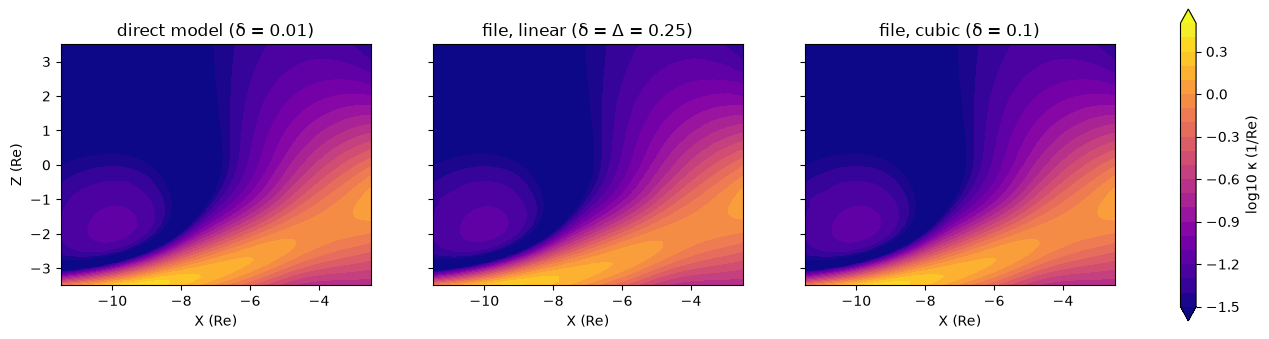

linear  curvature vs model (kappa > 0.05, 58% of points): median 5.8e-03, 95th pct 5.7e-02, max 1.5e-01
cubic   curvature vs model (kappa > 0.05, 58% of points): median 9.9e-04, 95th pct 8.3e-03, max 2.8e-02


In [5]:
xm = np.linspace(-11.5, -2.5, 73); zm = np.linspace(-3.5, 3.5, 57)
XM, ZM = np.meshgrid(xm, zm); YM = np.zeros_like(XM)
k_model = field_line_curvature(model, XM.ravel(), YM.ravel(), ZM.ravel(), delta=0.01).reshape(XM.shape)
k_lin = field_line_curvature(field_lin, XM.ravel(), YM.ravel(), ZM.ravel(), delta=dx).reshape(XM.shape)
k_cub = field_line_curvature(field_cub, XM.ravel(), YM.ravel(), ZM.ravel(), delta=0.1).reshape(XM.shape)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, k, title in zip(axes, (k_model, k_lin, k_cub), ("direct model (δ = 0.01)", "file, linear (δ = Δ = 0.25)", "file, cubic (δ = 0.1)")):
    c = ax.contourf(XM, ZM, np.log10(k), levels=np.linspace(-1.5, 0.5, 21), cmap="plasma", extend="both")
    ax.set_title(title); ax.set_xlabel("X (Re)"); ax.set_aspect("equal")
axes[0].set_ylabel("Z (Re)")
plt.colorbar(c, ax=axes, label="log10 κ (1/Re)", shrink=0.9)
plt.show()

# Relative error where the curvature is resolvable (the tail lobes have kappa -> 0,
# where any relative measure diverges).
sel = k_model > 0.05
for name, k in (("linear", k_lin), ("cubic", k_cub)):
    rel = np.abs(k / k_model - 1)[sel]
    print(f"{name:7s} curvature vs model (kappa > 0.05, {sel.mean():.0%} of points): "
          f"median {np.nanmedian(rel):.1e}, 95th pct {np.nanpercentile(rel, 95):.1e}, max {np.nanmax(rel):.1e}")

<a id="trace"></a>
## 5. Tracing through the data

`trace_field_lines` works on the interpolating callable directly. Outside the grid the interpolator returns NaN, which the tracer treats as a termination condition; passing `bounds=grid.bounds` reports those ends as boundary hits (`status` 1) with the last point placed exactly on the box face. The traced points then go back into the geometry functions — here the Frenet frame is evaluated along each line and checked for orthonormality.

FieldLineTrace(n_lines=9, max_points=70, status={'outer': 9})
status (+B end): [1 1 1 1 1 1 1 1 1]  status (-B end): [1 1 1 1 1 1 1 1 1]


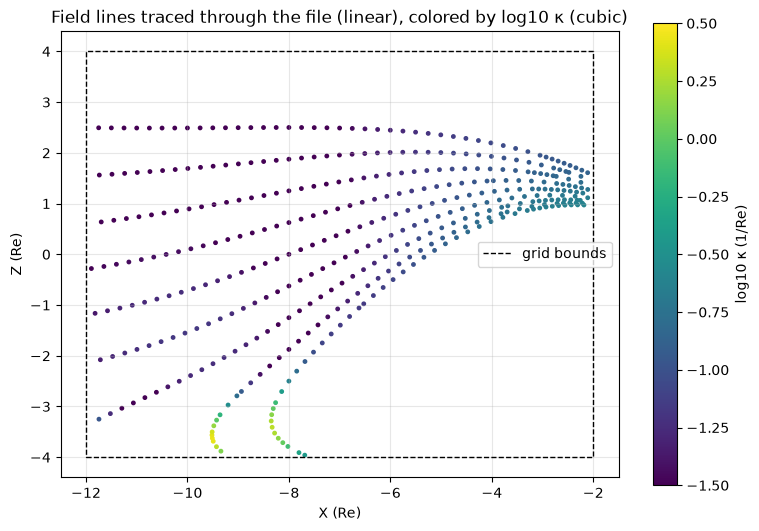

line 4: 70 points, 45 with a resolved frame (the rest lie in the weakly curved lobes); max orthonormality error 2.2e-16


In [6]:
seed_z = np.linspace(-2.5, 2.5, 9)
tr = trace_field_lines(field_lin, np.full_like(seed_z, -8.0), np.zeros_like(seed_z), seed_z,
                       direction="both", ds=dx, bounds=grid.bounds)
print(tr)
print("status (+B end):", tr.status, " status (-B end):", tr.status_backward)

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(tr.n_lines):
    x, y, z = tr.path(i)
    k = field_line_curvature(field_cub, x, y, z, delta=0.1)
    sc = ax.scatter(x, z, c=np.log10(k), s=6, cmap="viridis", vmin=-1.5, vmax=0.5)
(x0, x1), _, (z0, z1) = grid.bounds
ax.plot([x0, x1, x1, x0, x0], [z0, z0, z1, z1, z0], "k--", lw=1, label="grid bounds")
ax.set_aspect("equal"); ax.set_xlabel("X (Re)"); ax.set_ylabel("Z (Re)"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Field lines traced through the file (linear), colored by log10 κ (cubic)")
plt.colorbar(sc, ax=ax, label="log10 κ (1/Re)")
plt.show()

# Frenet frame along one line, through the file
x, y, z = tr.path(4)
frame = field_line_frenet_frame(field_cub, x, y, z, delta=0.1)
valid = np.isfinite(frame[3])   # NaN where the curvature is too small to resolve at this delta
from mageometry import verify_unit_vectors
errs = verify_unit_vectors(*(c[valid] for c in frame[:9]))
print(f"line 4: {x.size} points, {valid.sum()} with a resolved frame (the rest lie in the weakly curved "
      f"lobes); max orthonormality error {max(np.max(np.abs(e)) for e in errs.values()):.1e}")

<a id="own"></a>
## 6. Bringing your own data

- **XDMF + HDF5** in the convention above: `load_xdmf("run.xmf")` (pass `h5_file=` if the heavy-data file was renamed).
- **Plain HDF5** datasets: `load_hdf5("run.h5", datasets=("BX","BY","BZ"), origin=(x0,y0,z0), spacing=(dx,dy,dz))`.
- **Anything else** (VTK, NetCDF, in-memory arrays, non-uniform rectilinear grids): build the arrays yourself and construct `GriddedField(x, y, z, bx, by, bz)` directly. Units are your own throughout — rescale the axes or field arrays first if you need Re and nT.

Large runs rarely need to be loaded whole: every reader accepts `region=((xmin, xmax), (ymin, ymax), (zmin, zmax))` and `stride` to read only a sub-box or every n-th node (as an HDF5 hyperslab, so the full array never enters memory), and `GriddedField.subvolume` does the same for data already in memory. Time series (XDMF temporal collections or ParaView `.xmf.series` indexes) open lazily with `load_xdmf_series(path)` — `series.times`, `series[i]`, `series.at(t)`.

For example, a subvolume for detailed (cubic) analysis:

In [7]:
sub = grid.subvolume(region=((-10.0, -6.0), (-2.0, 2.0), (-2.0, 2.0)))
print(sub)
# the same box straight from the file, reading only those nodes:
print(load_xdmf(xmf_path, region=((-10.0, -6.0), (-2.0, 2.0), (-2.0, 2.0))))
k_sub = field_line_curvature(sub.field("cubic"), -8.0, 0.0, 0.0, delta=dx)
print(f"curvature at (-8, 0, 0): subvolume cubic {k_sub:.4f} | model {field_line_curvature(model, -8.0, 0.0, 0.0):.4f} 1/Re")

# clean up the temporary files
import shutil
shutil.rmtree(workdir, ignore_errors=True)

GriddedField(shape=(17, 17, 17), x=[-10, -6], y=[-2, 2], z=[-2, 2])
GriddedField(shape=(17, 17, 17), x=[-10, -6], y=[-2, 2], z=[-2, 2])
curvature at (-8, 0, 0): subvolume cubic 0.0105 | model 0.0105 1/Re
